In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from utils import *

data_path = "/jukebox/falkner/Jorge/Dexter_results/all_obs_xpo_pred_dict_v2_102325.pkl"
pub_path = "/usr/people/tt1131/projects/social_dojo_observer/fig/pub"

with open(data_path, "rb") as f:
    data_dict = pickle.load(f)
    
setup_plot_style()

In [3]:
mouse_id_list = list(data_dict.keys())[: -1] # get rid of the familiar vs novel first
categories_count_mtx = np.zeros((len(mouse_id_list), 4))
categories_count_mtx_full = np.zeros((len(mouse_id_list), 7))

for idx, mouse_id in enumerate(mouse_id_list):
    pred_full = data_dict[mouse_id]["prediction"]
    pred_smpl = pd.Series(label_to_categories(data_dict[mouse_id]["prediction"]))
    categories_count = (pred_full.value_counts() / len(pred_full)).to_dict()
    categories_count_full = (pred_full.value_counts() / len(pred_full)).to_dict()
    categories_count_smpl = (pred_smpl.value_counts() / len(pred_smpl)).to_dict()
    for uniq_category in np.arange(1, 5):
        categories_count_mtx[idx, uniq_category - 1] = categories_count_smpl.get(uniq_category, 0)
    for uniq_category in np.arange(7):
        categories_count_mtx_full[idx, uniq_category] = categories_count_full.get(uniq_category, 0)

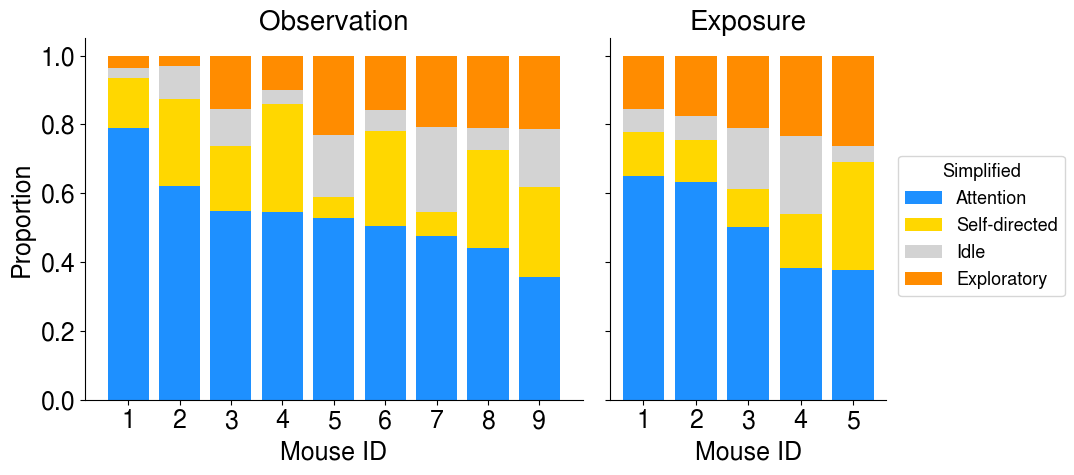

In [ ]:
colors = ["dodgerblue", "gold", "lightgray", "darkorange"]  # Different colors for each category
category_names = [categories_label_dict[i] for i in range(1, 5)]

fig, axs = plt.subplots(ncols = 2, figsize=(11, 5), sharey = True, gridspec_kw={'width_ratios': [1.8, 1]})

obs_id_list = np.array([i for i in mouse_id_list if label_to_cond_dict[i] == "obs"])
xpo_id_list = np.array([i for i in mouse_id_list if label_to_cond_dict[i] == "xpo"])

obs_id_indices = np.isin(mouse_id_list, obs_id_list)
xpo_id_indices = np.isin(mouse_id_list, xpo_id_list)

obs_count_mtx = categories_count_mtx[obs_id_indices, :]
xpo_count_mtx = categories_count_mtx[xpo_id_indices, :]

obs_attn_arg_sort = np.argsort(obs_count_mtx[:, 0])[::-1]
xpo_attn_arg_sort = np.argsort(xpo_count_mtx[:, 0])[::-1]

bottom = np.zeros(len(obs_id_list))
for i in range(4):
    axs[0].bar(range(len(obs_id_list)), obs_count_mtx[obs_attn_arg_sort, i], 
           bottom=bottom, label=category_names[i], color=colors[i])
    bottom += obs_count_mtx[obs_attn_arg_sort, i]

axs[0].set_xlabel('Mouse ID', fontsize = 18)
axs[0].set_ylabel('Proportion', fontsize = 18)
axs[0].set_title('Observation', fontsize = 20)
# axs[0].set_xticks(range(len(obs_id_list)), obs_id_list[obs_attn_arg_sort], rotation=45, fontsize = 12)
axs[0].set_xticks(range(len(obs_id_list)), np.arange(1, len(obs_id_list) + 1), fontsize = 18)
axs[0].set_yticks(np.arange(0, 1.1, 0.2), np.round(np.arange(0, 1.1, 0.2), 2), fontsize = 18)

bottom = np.zeros(len(xpo_id_list))
for i in range(4):
    axs[1].bar(range(len(xpo_id_list)), xpo_count_mtx[xpo_attn_arg_sort, i], 
           bottom=bottom, label=category_names[i], color=colors[i])
    bottom += xpo_count_mtx[xpo_attn_arg_sort, i]
    
axs[1].set_xlabel('Mouse ID', fontsize = 18)
axs[1].set_title('Exposure', fontsize = 20)
axs[1].set_xticks(range(len(xpo_id_list)), np.arange(1, len(xpo_id_list) + 1), fontsize = 18)
axs[1].set_yticks(np.arange(0, 1.1, 0.2), np.round(np.arange(0, 1.1, 0.2), 2), fontsize = 18)

axs[1].legend(bbox_to_anchor=(1.01, .7), loc='upper left', 
              title = "Simplified", fontsize = 13, title_fontsize = 13)

plt.tight_layout()
sns.despine()

plt.savefig(pub_path + "/proportion_plot_sort_attention.svg", format = "svg")
plt.show()

In [8]:
colors = ["gold", "darkorange", "peru", "palegoldenrod", "dodgerblue", "lightgray", "chocolate"] 
category_names = [name.title() for name in class_to_label_dict.keys()]
sorted_labels = ["Sniffing", "Grooming", "Scratching", "Still", "Turning", "Investigate", "Rearing"]
sorted_indices = [np.where(np.array(category_names) == label)[0][0] for label in sorted_labels]
sorted_indices

[4, 0, 3, 5, 6, 1, 2]

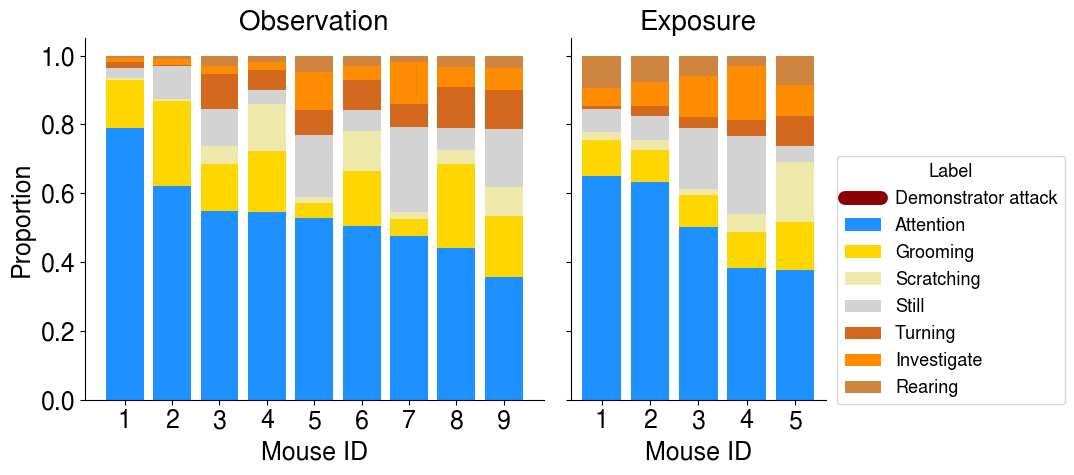

In [ ]:
# Instead we plot all behaviors
fig, axs = plt.subplots(ncols = 2, figsize=(11, 5), sharey = True, gridspec_kw={'width_ratios': [1.8, 1]})

obs_count_mtx_full = categories_count_mtx_full[obs_id_indices, :]
xpo_count_mtx_full = categories_count_mtx_full[xpo_id_indices, :]

full_sniff_idx = np.where(np.array(category_names) == "Sniffing")[0][0]
obs_attn_arg_sort = np.argsort(obs_count_mtx_full[:, full_sniff_idx])[::-1]
xpo_attn_arg_sort = np.argsort(xpo_count_mtx_full[:, full_sniff_idx])[::-1]

bottom = np.zeros(len(obs_id_list))
for i in sorted_indices:
    axs[0].bar(range(len(obs_id_list)), obs_count_mtx_full[obs_attn_arg_sort, i], 
           bottom=bottom, label= "Attention" if category_names[i] == "Sniffing" else category_names[i], color=colors[i])
    bottom += obs_count_mtx_full[obs_attn_arg_sort, i]

axs[0].set_xlabel('Mouse ID', fontsize = 18)
axs[0].set_ylabel('Proportion', fontsize = 18)
axs[0].set_title('Observation', fontsize = 20)
axs[0].set_xticks(range(len(obs_id_list)), np.arange(1, len(obs_id_list) + 1), fontsize = 18)
axs[0].set_yticks(np.arange(0, 1.1, 0.2), np.round(np.arange(0, 1.1, 0.2), 2), fontsize = 18)

bottom = np.zeros(len(xpo_id_list))
for i in sorted_indices:
    axs[1].bar(range(len(xpo_id_list)), xpo_count_mtx_full[xpo_attn_arg_sort, i], 
           bottom=bottom, label= "Attention" if category_names[i] == "Sniffing" else category_names[i], color=colors[i])
    bottom += xpo_count_mtx_full[xpo_attn_arg_sort, i]
    
axs[1].set_xlabel('Mouse ID', fontsize = 18)
axs[1].set_title('Exposure', fontsize = 20)
axs[1].set_xticks(range(len(xpo_id_list)), np.arange(1, len(xpo_id_list) + 1), fontsize = 18)
axs[1].set_yticks(np.arange(0, 1.1, 0.2), np.round(np.arange(0, 1.1, 0.2), 2), fontsize = 18)

axs[1].plot([], [], color = "darkred", linewidth = 10, alpha = 1, solid_capstyle = "round", label = "Demonstrator attack")

axs[1].legend(bbox_to_anchor=(1.01, .7), loc='upper left', 
              title = "Label", fontsize = 13, title_fontsize = 13)

plt.tight_layout()
sns.despine()

plt.savefig(pub_path + "/proportion_plot_full_sort_attention.svg", format = "svg")
plt.show()